# Analysis of the Relationship Between Product Categories and Sales Effectiveness (Inner)

## Member: Phuong

### Bàn luận:
Dựa trên phần EDA, ta có thể thấy có 5 root mỗi root chứa nhiều middle, mỗi middle chứa nhiều leaf
Vì vậy có rất nhiều thứ cần phải phân tích trong một danh mục.
Để đảm bảo insight được khách quan và thực sự cung cấp thông tin hữu ích cho người đọc. Em sẽ tiếp cận bằng một mục tiêu phân tích bao quát nhất

### Analysis Objectives:
1. **Question 1**: Với từng root danh mục, danh mục con trực tiếp nào đang phát triển mạnh nhất (doanh thu, số danh mục con, tổng sản phẩm)?
2. **Question 2**: Khám phá chuyên sâu những danh mục phát triển mạnh nhất đó xem yếu tố nào chính là yếu tố ảnh hưởng lớn nhất (Dùng linear để predict doanh thu xem cái nào có trọng số cao nhất)?
attributes: trong bảng product
target: price * sold_count


!!! - Chấp nhận rằng linear chỉ cho bạn insight tuyến tính, không phải là “chân lý” nhân quả.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from IPython.display import display

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler


import os
import warnings
warnings.filterwarnings('ignore')

# Display configuration
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)


# Create output directory if not exists
output_dir = '../output'
os.makedirs(output_dir, exist_ok=True)

## 1. Load Common Data

In [46]:
# Load 4 common data tables following team standards
df_store = pd.read_csv('../data/stores.csv')
df_category = pd.read_csv('../data/categories.csv')
df_product = pd.read_csv('../data/products.csv')
df_review = pd.read_csv('../data/reviews.csv')

print("Data Size:")
print(f"Stores: {df_store.shape}")
print(f"Categories: {df_category.shape}")
print(f"Products: {df_product.shape}")
print(f"Reviews: {df_review.shape}")

Data Size:
Stores: (1446, 5)
Categories: (497, 4)
Products: (55883, 14)
Reviews: (158126, 8)


## 2. Category Exploration
- Khám phá các root category (trỏng có bao nhiêu nhánh)
- EDA cơ bản về dữ liệu từng category (doanh thu tổng, chart danh thu cho từng category)
- ...

In [ ]:
# preprocess xong thì bỏ
df_category = df_category.copy()
df_category['category_id'] = df_category['category_id'].astype(int)
df_category['category_name'] = df_category['category_name'].astype(str).str.strip()
df_category['parent_category_clean'] = df_category['parent_category'].fillna('').astype(str).str.strip()

⏳ Đang xử lý dữ liệu cho phần EDA Tổng quan...


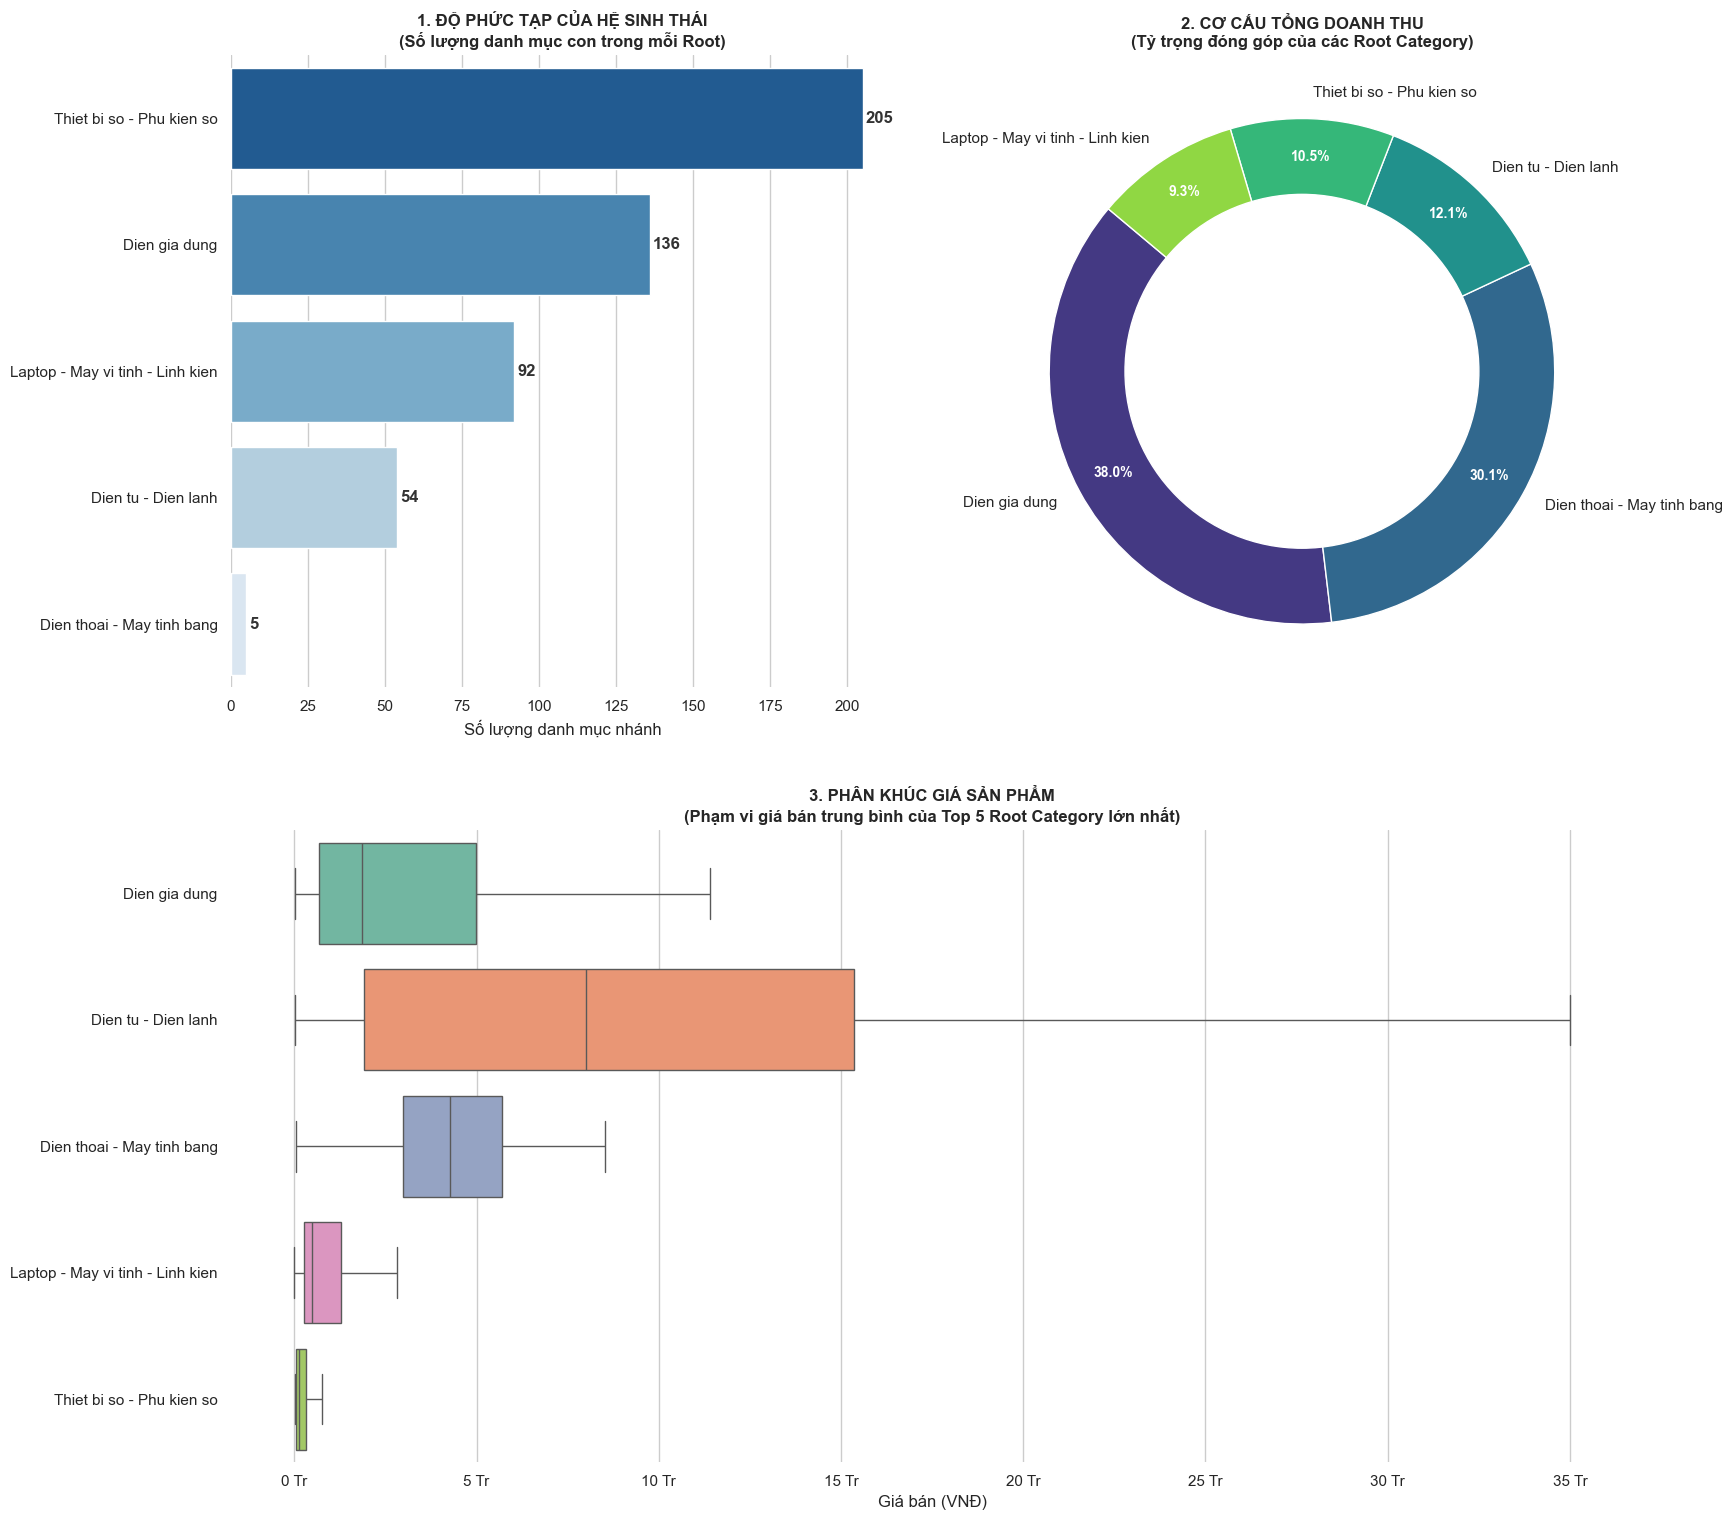


--- BẢNG TÓM TẮT TỔNG QUAN ---


,total_items,total_revenue
root_category,,
Dien gia dung,"11,884",472.22 Tỷ
Dien thoai - May tinh bang,161,374.13 Tỷ
Dien tu - Dien lanh,"2,046",150.86 Tỷ
Thiet bi so - Phu kien so,"30,528",130.12 Tỷ
Laptop - May vi tinh - Linh kien,"11,264",115.75 Tỷ


In [ ]:
# 1. Làm sạch dữ liệu danh mục (nếu chưa làm ở các bước trước)


# 2. Xây dựng hàm dò tìm tổ tiên xa nhất (Root Category)
parent_dict = dict(zip(df_category['category_name_clean'], df_category['parent_category_clean']))

def get_root_category(cat_name):
    """Hàm dò ngược từ 1 danh mục lá lên tận danh mục gốc (Root)"""
    current = cat_name
    visited = set()
    while current in parent_dict and parent_dict[current] != '':
        if current in visited: 
            break # Chống lặp vô hạn
        visited.add(current)
        current = parent_dict[current]
    return current

# Ánh xạ Root cho toàn bộ bảng Category
df_category['root_category'] = df_category['category_name_clean'].apply(get_root_category)
cat_to_root_dict = dict(zip(df_category['category_id'], df_category['root_category']))

# 3. Ánh xạ Root xuống bảng Product và tính Doanh thu
df_product_eda = df_product.copy()
df_product_eda['category_id'] = df_product_eda['category_id'].astype(str)
df_product_eda['root_category'] = df_product_eda['category_id'].map(cat_to_root_dict)

df_product_eda['price'] = pd.to_numeric(df_product_eda['price'], errors='coerce').fillna(0)
df_product_eda['sold_count'] = pd.to_numeric(df_product_eda['sold_count'], errors='coerce').fillna(0)
df_product_eda['revenue'] = df_product_eda['price'] * df_product_eda['sold_count']


# ==========================================
# TRỰC QUAN HÓA (VISUALIZATION)
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style="whitegrid", palette="muted")

# Khởi tạo Figure gồm 3 biểu đồ
fig = plt.figure(figsize=(18, 16))

# Tùy chỉnh formatter tiền tệ (Triệu / Tỷ VNĐ)
def format_money(x, pos):
    if x >= 1_000_000_000:
        return f'{x / 1_000_000_000:,.1f} Tỷ'
    return f'{x / 1_000_000:,.0f} Tr'

# ---------------------------------------------------------
# CHART 1: SỐ LƯỢNG NHÁNH CON TRONG TỪNG ROOT (BAR CHART)
# ---------------------------------------------------------
ax1 = plt.subplot(2, 2, 1)
# Đếm số danh mục con (chỉ tính những danh mục không phải là Root)
sub_cat_count = df_category[df_category['parent_category_clean'] != ''].groupby('root_category')['category_id'].count().sort_values(ascending=False)

sns.barplot(x=sub_cat_count.values, y=sub_cat_count.index, palette="Blues_r", ax=ax1)
ax1.set_title('1. ĐỘ PHỨC TẠP CỦA HỆ SINH THÁI\n(Số lượng danh mục con trong mỗi Root)', fontweight='bold')
ax1.set_xlabel('Số lượng danh mục nhánh')
ax1.set_ylabel('')
# Gắn text số lượng
for i, v in enumerate(sub_cat_count.values):
    ax1.text(v + 1, i, str(v), va='center', fontweight='bold', color='#333333')

# ---------------------------------------------------------
# CHART 2: TỔNG DOANH THU THEO TỪNG ROOT (DONUT CHART)
# ---------------------------------------------------------
ax2 = plt.subplot(2, 2, 2)
# Tổng hợp doanh thu
revenue_by_root = df_product_eda.groupby('root_category')['revenue'].sum().sort_values(ascending=False)
# Lọc bỏ các Root có doanh thu = 0 để biểu đồ không bị rác
revenue_by_root = revenue_by_root[revenue_by_root > 0]

# Vẽ Donut Chart
wedges, texts, autotexts = ax2.pie(
    revenue_by_root.values, 
    labels=revenue_by_root.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    pctdistance=0.85,
    colors=sns.color_palette("viridis", len(revenue_by_root))
)
# Tạo khoảng trống ở giữa để thành Donut
centre_circle = plt.Circle((0,0), 0.70, fc='white')
ax2.add_artist(centre_circle)
# Tùy chỉnh text
plt.setp(autotexts, size=10, weight="bold", color="white")
ax2.set_title('2. CƠ CẤU TỔNG DOANH THU\n(Tỷ trọng đóng góp của các Root Category)', fontweight='bold')

# ---------------------------------------------------------
# CHART 3: PHÂN BỐ GIÁ BÁN SẢN PHẨM (BOXPLOT)
# ---------------------------------------------------------
ax3 = plt.subplot(2, 1, 2) # Chiếm toàn bộ hàng dưới
# Chỉ lấy top 5 Root có nhiều sản phẩm nhất để vẽ Boxplot cho đỡ rối
top5_roots_by_items = df_product_eda['root_category'].value_counts().head(5).index
df_boxplot = df_product_eda[(df_product_eda['root_category'].isin(top5_roots_by_items)) & (df_product_eda['price'] > 0)]

sns.boxplot(
    data=df_boxplot, 
    x='price', 
    y='root_category', 
    palette="Set2",
    showfliers=False, # Ẩn các điểm outliers (như sản phẩm giá chục tỷ) để nhìn rõ phân khúc chính
    ax=ax3
)
ax3.xaxis.set_major_formatter(FuncFormatter(format_money))
ax3.set_title('3. PHÂN KHÚC GIÁ SẢN PHẨM\n(Phạm vi giá bán trung bình của Top 5 Root Category lớn nhất)', fontweight='bold')
ax3.set_xlabel('Giá bán (VNĐ)')
ax3.set_ylabel('')

# ---------------------------------------------------------
plt.tight_layout(pad=3.0)
sns.despine(left=True, bottom=True)
plt.show()

# In thêm bảng tóm tắt bằng số
print("\n--- BẢNG TÓM TẮT TỔNG QUAN ---")
summary_table = df_product_eda.groupby('root_category').agg(
    total_items=('product_id', 'count'),
    total_revenue=('revenue', 'sum')
).sort_values('total_revenue', ascending=False)

# Format hiển thị
display(summary_table.style.format({
    'total_items': '{:,.0f}',
    'total_revenue': lambda x: f"{x/1_000_000:,.1f} Tr" if x < 1_000_000_000 else f"{x/1_000_000_000:,.2f} Tỷ"
}))

## 3. Question 1: 

Chốt: doanh thu = discounted_price (nếu có) * sold (nếu không có discounted_price thì dùng price)
Note: nói trong câu 1 là mình chấp nhận tính tương đối của doanh thu

In [47]:
import pandas as pd
from IPython.display import display

# ==========================================
# PHẦN 1: CHUẨN HÓA VÀ XÂY DỰNG CÂY DANH MỤC
# ==========================================

df_category = df_category.copy()
df_category['category_id'] = df_category['category_id'].astype(str)
df_category['category_name_clean'] = df_category['category_name'].astype(str).str.strip()
df_category['parent_category_clean'] = df_category['parent_category'].fillna('').astype(str).str.strip()

# 1. Xác định Root categories (cấp 1)
root_categories = df_category.loc[
    df_category['parent_category_clean'] == '', 
    ['category_id', 'category_name_clean']
].rename(columns={'category_name_clean': 'root_name'})
root_names_set = set(root_categories['root_name'])

# 2. Xây dựng hàm dò tìm tổ tiên cấp 2 (L2 Ancestor)
parent_dict = dict(zip(df_category['category_name_clean'], df_category['parent_category_clean']))

def get_l2_ancestor(cat_name):
    """Hàm dò ngược từ 1 danh mục bất kỳ lên danh mục cấp 2 (con trực tiếp của Root)"""
    current = cat_name
    visited = set()
    while current and current in parent_dict:
        parent = parent_dict[current]
        if parent in root_names_set:
            return current  # Đã tìm thấy danh mục cấp 2
        if current in visited:
            break  # Chống lặp vô hạn nếu data bị lỗi vòng lặp
        visited.add(current)
        current = parent
    return None

# Map L2_ancestor cho TOÀN BỘ danh mục
df_category['L2_ancestor'] = df_category['category_name_clean'].apply(get_l2_ancestor)

# 3. Đếm số danh mục con trực tiếp cho mục đích hiển thị
child_counts = df_category.groupby('parent_category_clean')['category_id'].count()


# ==========================================
# PHẦN 2: TÍNH DOANH THU & ROLL-UP DỮ LIỆU
# ==========================================

df_product = df_product.copy()
df_product['category_id'] = df_product['category_id'].astype(str)
df_product['price'] = df_product['price'].astype(float)
df_product['sold_count'] = df_product['sold_count'].fillna(0).astype(int)
df_product['revenue'] = df_product['price'] * df_product['sold_count']

# Map sản phẩm với danh mục cấp 2 tương ứng của nó
cat_to_l2_dict = dict(zip(df_category['category_id'], df_category['L2_ancestor']))
df_product['L2_ancestor'] = df_product['category_id'].map(cat_to_l2_dict)

# Gom nhóm theo L2_ancestor THAY VÌ category_id trực tiếp
if 'product_id' in df_product.columns:
    cat_revenue = df_product.groupby('L2_ancestor', as_index=False).agg(
        total_revenue=('revenue', 'sum'),
        product_count=('product_id', 'nunique'),
    )
else:
    cat_revenue = df_product.groupby('L2_ancestor', as_index=False).agg(
        total_revenue=('revenue', 'sum'),
        product_count=('revenue', 'size'),
    )


# ==========================================
# PHẦN 3: LỌC TOP 1 CHO MỖI ROOT
# ==========================================

# Chỉ lấy danh sách các danh mục cấp 2 (con trực tiếp của Root) để làm khung báo cáo
q1_summary = df_category[df_category['parent_category_clean'].isin(root_names_set)].copy()

q1_summary = q1_summary[['category_id', 'category_name_clean', 'parent_category_clean']].rename(
    columns={'parent_category_clean': 'root_name'}
)
q1_summary['direct_child_count'] = q1_summary['category_name_clean'].map(child_counts).fillna(0).astype(int)

# Gộp tổng doanh thu đã cuộn (Roll-up) vào bảng
q1_summary = q1_summary.merge(cat_revenue, left_on='category_name_clean', right_on='L2_ancestor', how='left')
q1_summary['total_revenue'] = q1_summary['total_revenue'].fillna(0)
q1_summary['product_count'] = q1_summary['product_count'].fillna(0).astype(int)
q1_summary = q1_summary.drop(columns=['L2_ancestor'])

# Sắp xếp và lấy Top 1
q1_summary = q1_summary.sort_values(by=['total_revenue', 'product_count'], ascending=[False, False])
top1_per_root = q1_summary.groupby('root_name').head(1).reset_index(drop=True)

# Format Index lại từ 1
top1_per_root.index = top1_per_root.index + 1


# ==========================================
# PHẦN 4: HIỂN THỊ TRỰC QUAN
# ==========================================

def format_to_millions(val):
    if pd.isna(val): return val
    return f"{val / 1_000_000:,.2f} Tr"

fmt_summary = {'total_revenue': format_to_millions}

print('--- 1. Root categories ---')
display(root_categories)

print('\n--- 2. Danh mục con trực tiếp xuất sắc nhất của TỪNG Root Category ---')
display(top1_per_root[['root_name', 'category_id', 'category_name_clean', 'direct_child_count', 'product_count', 'total_revenue']].style.format(fmt_summary))

--- 1. Root categories ---


,category_id,root_name
0,1882,Dien gia dung
138,1789,Dien thoai - May tinh bang
144,4221,Dien tu - Dien lanh
198,1846,Laptop - May vi tinh - Linh kien
291,1815,Thiet bi so - Phu kien so



--- 2. Danh mục con trực tiếp xuất sắc nhất của TỪNG Root Category ---


,root_name,category_id,category_name_clean,direct_child_count,product_count,total_revenue
1,Dien thoai - May tinh bang,1795,Điện thoại Smartphone,0,117,"368,812.27 Tr"
2,Dien gia dung,1884,Đồ dùng nhà bếp,24,7128,"332,858.66 Tr"
3,Dien tu - Dien lanh,3862,Máy giặt,4,225,"111,206.29 Tr"
4,Laptop - May vi tinh - Linh kien,12884,Thiết Bị Văn Phòng - Thiết Bị Ngoại Vi,13,3460,"91,966.67 Tr"
5,Thiet bi so - Phu kien so,28670,Phụ kiện máy tính và Laptop,10,4968,"48,916.68 Tr"


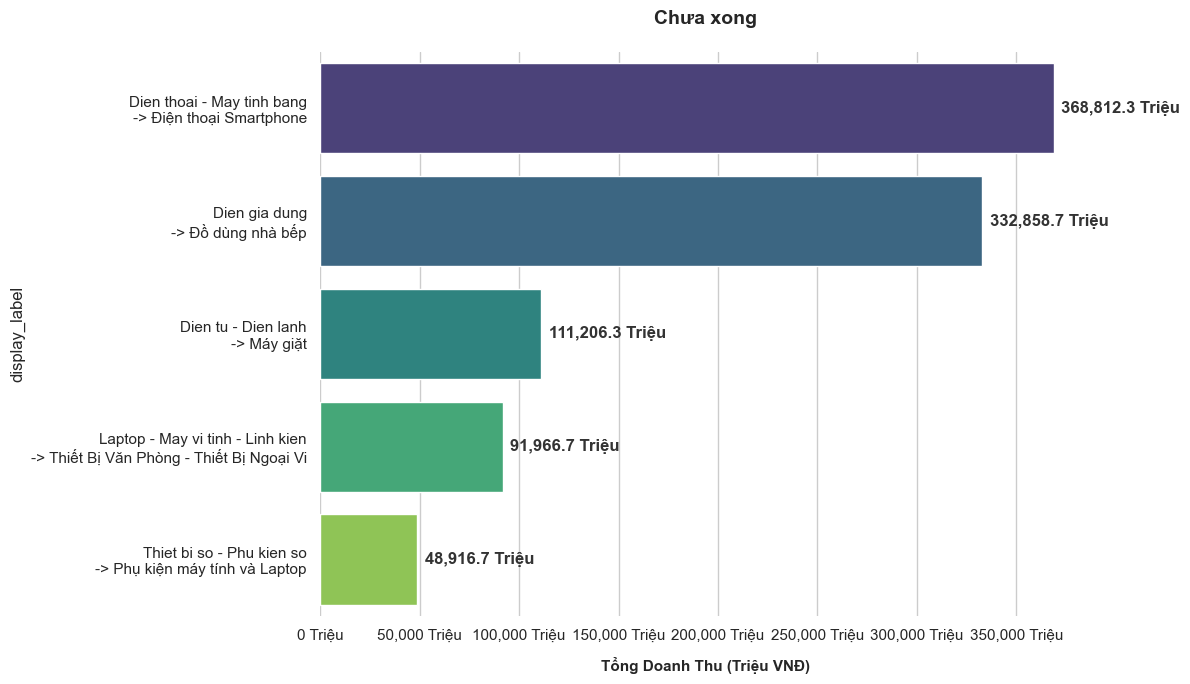

In [48]:
# 2. Tạo một cột nhãn mới gộp cả tên Root và Tên Child để dễ đọc trên biểu đồ
# Ví dụ: "Đồ gia dụng \n-> Đồ dùng nhà bếp"
top1_per_root_plot = top1_per_root.copy()
top1_per_root_plot['display_label'] = top1_per_root_plot['root_name'] + '\n-> ' + top1_per_root_plot['category_name_clean']

# Sắp xếp lại dữ liệu theo doanh thu giảm dần để biểu đồ đẹp hơn (như bậc thang)
top1_per_root_plot = top1_per_root_plot.sort_values('total_revenue', ascending=False)

# 3. Khởi tạo Figure
plt.figure(figsize=(12, 7))

# 4. Vẽ biểu đồ cột ngang (Barplot)
ax = sns.barplot(
    data=top1_per_root_plot,
    x='total_revenue',
    y='display_label',
    palette='viridis', # Tone màu từ đậm đến nhạt nhìn rất chuyên nghiệp
    hue='display_label', # Thêm hue để gán màu theo từng dòng, tránh warning của Seaborn mới
    legend=False
)

# 5. Format trục X về đơn vị Triệu (Tr)
def millions_formatter(x, pos):
    return f'{x / 1_000_000:,.0f} Triệu'
ax.xaxis.set_major_formatter(FuncFormatter(millions_formatter))

# 6. Thêm Text hiển thị số tiền chính xác ngay đuôi mỗi cột
max_revenue = top1_per_root_plot['total_revenue'].max()
for i, v in enumerate(top1_per_root_plot['total_revenue']):
    # Vị trí text xê dịch một chút sang phải so với đuôi cột (khoảng 1% của max_revenue)
    ax.text(v + (max_revenue * 0.01), i, 
            f'{v / 1_000_000:,.1f} Triệu', 
            va='center', fontweight='bold', color='#333333')

# 7. Căn chỉnh Tiêu đề và Nhãn trục
plt.title('Chưa xong', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Tổng Doanh Thu (Triệu VNĐ)', fontsize=11, fontweight='bold', labelpad=10)

# Bỏ đường viền trên và phải cho biểu đồ thoáng hơn
sns.despine(left=True, bottom=True)

# 8. Hiển thị
plt.tight_layout()
plt.show()

### Analysis and Conclusion - Question 1

#### Key Observations:

1. 
2. 
3. 
#### Conclusion:


## 4. Question 2: 

Methodological Notes:

- Revenue is approximated as price × sold_count, acknowledging potential measurement noise (e.g., missing discounts).
- Only features available at or before the point of sale are considered in the main modeling phase to reduce data leakage risk.
- Review-based features are analyzed separately as post-purchase signals to understand customer engagement patterns rather than as predictive drivers.
- XGBoost is used to capture non-linear relationships and interactions between variables.
- Feature importance is interpreted as contribution to prediction, not causal effect.

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from IPython.display import display

# ==========================================
# BƯỚC 1: FEATURE ENGINEERING TỪ DF_REVIEW
# ==========================================
print("⏳ Đang xử lý Feature Engineering từ các bảng...")
df_review = df_review.copy()
df_product = df_product.copy()
df_store = df_store.copy()

# Ép kiểu ID về chuỗi để tránh lỗi khi gộp (Merge)
df_product['product_id'] = df_product['product_id'].astype(str)
df_product['store_id'] = df_product['store_id'].astype(str)
df_store['store_id'] = df_store['store_id'].astype(str)
df_review['product_id'] = df_review['product_id'].astype(str)

# Ép kiểu cho các cột review
df_review['like_count'] = pd.to_numeric(df_review['like_count'], errors='coerce').fillna(0)
# Tạo biến mới: Độ dài chữ của review (Review càng dài thường càng có tâm)
df_review['review_length'] = df_review['review_text'].astype(str).apply(len)

# Gom nhóm Review theo từng Sản phẩm
review_agg = df_review.groupby('product_id', as_index=False).agg(
    total_review_likes=('like_count', 'sum'),
    avg_review_length=('review_length', 'mean')
)

# ==========================================
# BƯỚC 2: GỘP 3 BẢNG (MERGE) VÀ TẠO TARGET
# ==========================================
# 1. Gộp Review vào Product
df_merged = df_product.merge(review_agg, on='product_id', how='left')

# 2. Gộp Store vào Product (Chỉ lấy các cột mang tính phân tích)
store_features = df_store[['store_id', 'store_rating', 'follower_count']]
# Đảm bảo numeric
store_features['store_rating'] = pd.to_numeric(store_features['store_rating'], errors='coerce')
store_features['follower_count'] = pd.to_numeric(store_features['follower_count'], errors='coerce')

df_merged = df_merged.merge(store_features, on='store_id', how='left')

# 3. Tính Target: Revenue
df_merged['price'] = pd.to_numeric(df_merged['price'], errors='coerce').fillna(0)
df_merged['sold_count'] = pd.to_numeric(df_merged['sold_count'], errors='coerce').fillna(0)
df_merged['revenue'] = df_merged['price'] * df_merged['sold_count']

# Cập nhật lại cột L2_ancestor (ánh xạ từ danh mục gốc của Câu 1)
# Giả định dict 'cat_to_l2_dict' vẫn còn lưu từ block code trước của bạn
df_merged['category_id'] = df_merged['category_id'].astype(str)
df_merged['L2_ancestor'] = df_merged['category_id'].map(cat_to_l2_dict)

# ==========================================
# BƯỚC 3: LỌC DỮ LIỆU TOP 1 & CHUẨN BỊ FEATURES
# ==========================================
top1_names = top1_per_root['category_name_clean'].tolist()
df_top_products = df_merged[df_merged['L2_ancestor'].isin(top1_names)].copy()

# Xác định rõ các biến (Features) sẽ đưa vào mô hình
features = [
    'discount_percent', # Nhóm giá cả
    'rating_avg', 'review_count',                  # Nhóm tương tác trực tiếp SP
    'total_review_likes', 'avg_review_length',     # Nhóm tương tác Review (Tạo mới)
    'store_rating', 'follower_count'               # Nhóm uy tín Store
]

# Chuyển đổi toàn bộ features sang dạng số và điền 0 cho dữ liệu NaN
for col in features:
    df_top_products[col] = pd.to_numeric(df_top_products[col], errors='coerce').fillna(0)

print(f"✅ Đã gộp thành công! Tổng số sản phẩm phân tích: {len(df_top_products):,}")

# ==========================================
# BƯỚC 4: HÀM TRAIN MÔ HÌNH VÀ TÍNH TRỌNG SỐ
# ==========================================
def get_linear_weights(df, feature_cols, target_col='revenue'):
    X = df[feature_cols]
    y = df[target_col]
    
    # Chuẩn hóa StandardScaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Fit Linear Regression
    model = LinearRegression()
    model.fit(X_scaled, y)
    
    # Bảng trọng số
    df_weights = pd.DataFrame({'Attribute': feature_cols, 'Weight': model.coef_})
    df_weights['Impact_Magnitude'] = np.abs(df_weights['Weight'])
    return df_weights.sort_values(by='Impact_Magnitude', ascending=False).reset_index(drop=True)

# A. Chạy mô hình CHUNG
global_weights = get_linear_weights(df_top_products, features)

# B. Chạy mô hình RIÊNG cho từng Top 1 Category
local_weights_dict = {}
for cat in top1_names:
    df_cat = df_top_products[df_top_products['L2_ancestor'] == cat]
    if len(df_cat) >= 5: # Chỉ train nếu có đủ dữ liệu
        local_weights_dict[cat] = get_linear_weights(df_cat, features)
    else:
        print(f"⚠️ Bỏ qua '{cat}' do chỉ có {len(df_cat)} sản phẩm.")

⏳ Đang xử lý Feature Engineering từ các bảng...
✅ Đã gộp thành công! Tổng số sản phẩm phân tích: 15,898


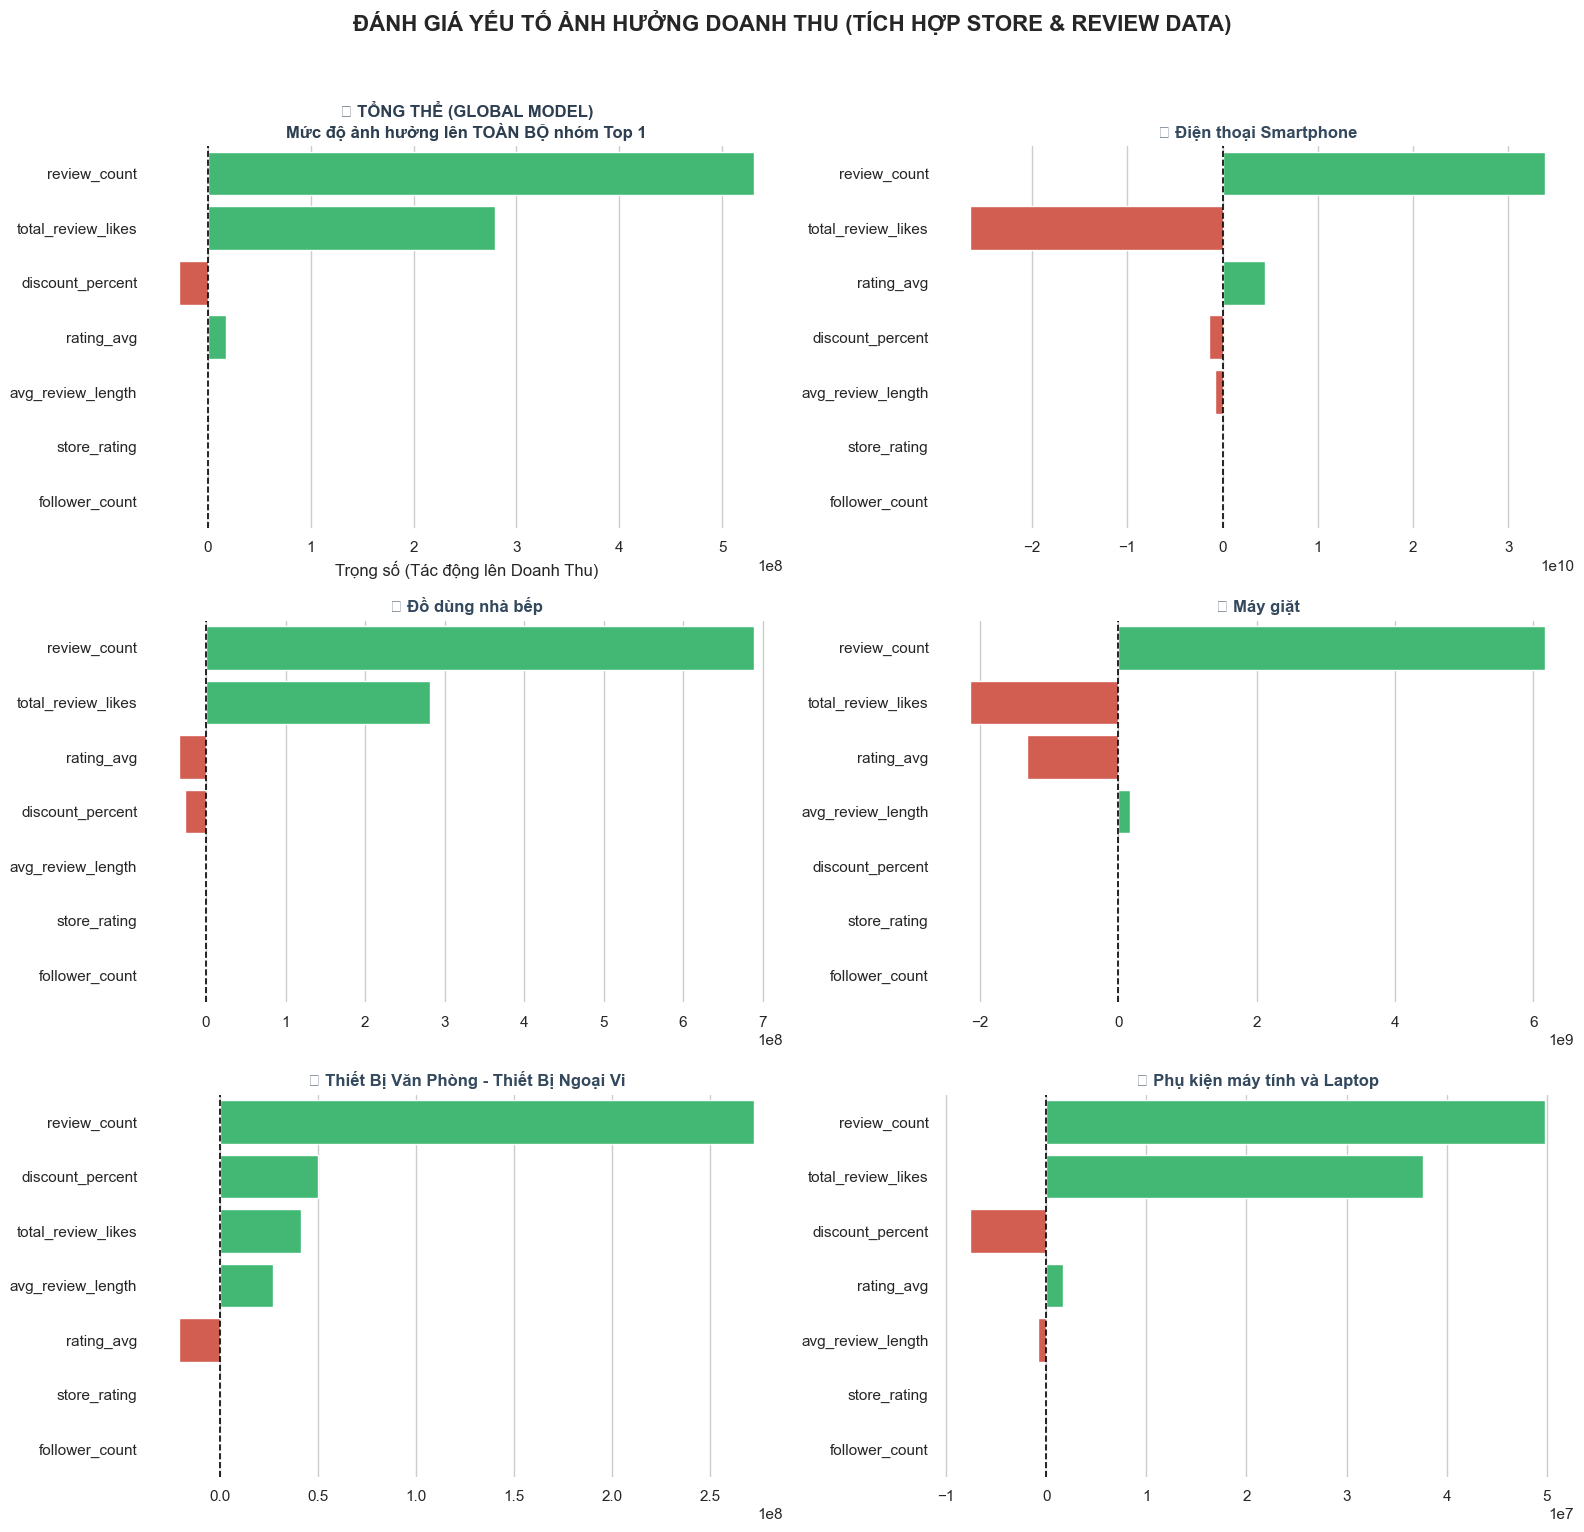

In [51]:
# ==========================================
# BƯỚC 5: TRỰC QUAN HÓA BẰNG GRID SUBPLOTS
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style="whitegrid")

num_plots = 1 + len(local_weights_dict)
cols = 2
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
axes = axes.flatten()

def plot_weights_on_ax(ax, df_w, title, is_global=False):
    colors = ['#2ecc71' if w > 0 else '#e74c3c' for w in df_w['Weight']]
    sns.barplot(data=df_w, x='Weight', y='Attribute', palette=colors, hue='Attribute', legend=False, ax=ax)
    ax.axvline(x=0, color='black', linewidth=1.2, linestyle='--')
    
    if is_global:
        ax.set_title(f'🌟 TỔNG THỂ (GLOBAL MODEL)\n{title}', fontsize=12, fontweight='bold', color='#2c3e50')
    else:
        ax.set_title(f'📁 {title}', fontsize=12, fontweight='bold', color='#34495e')
        
    ax.set_xlabel('Trọng số (Tác động lên Doanh Thu)' if is_global else '')
    ax.set_ylabel('')
    sns.despine(ax=ax, left=True, bottom=True)

# Vẽ Global Model
plot_weights_on_ax(axes[0], global_weights, 'Mức độ ảnh hưởng lên TOÀN BỘ nhóm Top 1', is_global=True)

# Vẽ Local Models
plot_idx = 1
for cat_name, df_w in local_weights_dict.items():
    plot_weights_on_ax(axes[plot_idx], df_w, cat_name)
    plot_idx += 1

# Xóa các trục bị dư
for i in range(plot_idx, len(axes)):
    fig.delaxes(axes[i])

plt.suptitle('ĐÁNH GIÁ YẾU TỐ ẢNH HƯỞNG DOANH THU (TÍCH HỢP STORE & REVIEW DATA)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

review_count ảnh hưởng tích cực và trực tiếp nhất
total_review ảnh hưởng tích cực và đóng góp nhiều cho kq trong hầu hết trừ 2 danh mục (smartphone và máy giặt)

nếu khám phá từng cái thì sẽ khám phá cái gì?
- khám phá thử xem tại sao total_review_likes lại gây ảnh hưởng tiêu cực đến 2 nhóm này
- tại sao discounted percent lại gây ảnh hưởng âm ở 1 số nhóm

2.1 total_review_likes là gì?
- print total_review_likes của 5 danh mục
- 

In [52]:
# --- CODE CHO TO-DO 2.1 ---
print("--- KHÁM PHÁ TOTAL_REVIEW_LIKES CHO 5 DANH MỤC ---\n")

# 1. Print tổng/trung bình likes của 5 danh mục
likes_summary = df_top_products.groupby('L2_ancestor').agg(
    total_products=('product_id', 'count'),
    avg_likes_per_product=('total_review_likes', 'mean'),
    max_likes_on_one_product=('total_review_likes', 'max')
).sort_values('avg_likes_per_product', ascending=False)

display(likes_summary.style.format('{:,.1f}'))

# 2. Khám phá sâu: Lượt Like thường dồn vào Review 5 sao hay 1-2 sao?
# Ta sẽ merge L2_ancestor vào bảng df_review để xem xét
df_review_extended = df_review.merge(df_product[['product_id', 'category_id']], on='product_id', how='left')
df_review_extended['L2_ancestor'] = df_review_extended['category_id'].map(cat_to_l2_dict)

# Lọc riêng 5 danh mục Top 1
df_top_reviews = df_review_extended[df_review_extended['L2_ancestor'].isin(top1_names)].copy()
df_top_reviews['rating'] = pd.to_numeric(df_top_reviews['rating'], errors='coerce')

# Tính số Like trung bình mà mỗi loại Rating (1->5 sao) nhận được
# Nhìn vào đây sẽ biết khách hàng hay bấm Like cho bài chê hay bài khen
rating_likes_corr = df_top_reviews.groupby(['L2_ancestor', 'rating'])['like_count'].mean().unstack()

print("\n--- Trung bình số lượt Like mà 1 bài Review nhận được (chia theo số Sao) ---")
print("=> Nếu cột 1, 2 sao có số Like cao vọt, chứng tỏ khách hàng rất hay Like các bài 'bóc phốt'")
display(rating_likes_corr.style.background_gradient(cmap='Reds', axis=1).format("{:.1f}"))

--- KHÁM PHÁ TOTAL_REVIEW_LIKES CHO 5 DANH MỤC ---



,total_products,avg_likes_per_product,max_likes_on_one_product
L2_ancestor,,,
Điện thoại Smartphone,117.0,4.9,471.0
Đồ dùng nhà bếp,"7,128.0",1.6,"1,084.0"
Thiết Bị Văn Phòng - Thiết Bị Ngoại Vi,"3,460.0",0.9,815.0
Phụ kiện máy tính và Laptop,"4,968.0",0.5,226.0
Máy giặt,225.0,0.0,3.0



--- Trung bình số lượt Like mà 1 bài Review nhận được (chia theo số Sao) ---
=> Nếu cột 1, 2 sao có số Like cao vọt, chứng tỏ khách hàng rất hay Like các bài 'bóc phốt'


rating,1,2,3,4,5
L2_ancestor,,,,,
Máy giặt,0.0,1.5,0.0,0.1,0.1
Phụ kiện máy tính và Laptop,0.6,0.4,0.4,0.1,0.1
Thiết Bị Văn Phòng - Thiết Bị Ngoại Vi,0.7,1.1,0.9,0.4,0.3
Điện thoại Smartphone,0.0,0.0,0.0,0.0,0.4
Đồ dùng nhà bếp,1.4,1.3,1.0,0.3,0.2


xem xem những review nào được like nhiều nhất trong từng danh mục

to-do:
- print top 5 review nhiều like nhất của các danh mục này

In [53]:
print("--- KHÁM PHÁ TOP 5 REVIEW ĐƯỢC LIKE NHIỀU NHẤT TRONG TỪNG DANH MỤC TOP 1 ---\n")

# 1. Merge thêm product_name từ df_product vào df_review để biết review đang nói về sản phẩm nào
df_review_full = df_review.merge(
    df_product[['product_id', 'product_name', 'category_id']],
    on='product_id',
    how='left'
)

# 2. Map lại L2_ancestor (danh mục gốc) dựa vào từ điển cat_to_l2_dict đã có
df_review_full['L2_ancestor'] = df_review_full['category_id'].map(cat_to_l2_dict)

# 3. Lọc lấy các bài review thuộc nhánh của các Top 1 Category
top1_names = top1_per_root['category_name_clean'].tolist()
df_top_reviews = df_review_full[df_review_full['L2_ancestor'].isin(top1_names)].copy()

# Ép kiểu dữ liệu để đảm bảo hàm sort hoạt động đúng
df_top_reviews['like_count'] = pd.to_numeric(df_top_reviews['like_count'], errors='coerce').fillna(0).astype(int)
df_top_reviews['rating'] = pd.to_numeric(df_top_reviews['rating'], errors='coerce')

# 4. Sắp xếp giảm dần theo Like và lấy Top 5 cho TỪNG danh mục
top5_reviews_per_cat = (
    df_top_reviews.sort_values(by=['L2_ancestor', 'like_count'], ascending=[True, False])
    .groupby('L2_ancestor')
    .head(5)
)

# 5. In kết quả trực quan (Tách riêng từng bảng cho từng Danh mục)
for cat in top1_names:
    print(f"📌 DANH MỤC: {cat.upper()}")
    
    # Copy để tránh warning của Pandas khi tạo cột mới
    cat_reviews = top5_reviews_per_cat[top5_reviews_per_cat['L2_ancestor'] == cat].copy()
    
    if cat_reviews.empty:
        print("   -> Không có dữ liệu review cho danh mục này.\n")
        continue

    # Cắt ngắn text để bảng hiển thị không bị tràn màn hình (giới hạn 150 ký tự cho review, 50 ký tự cho tên SP)
    cat_reviews['Nội dung Review'] = cat_reviews['review_text'].astype(str).apply(
        lambda x: x[:150] + '...' if len(x) > 150 else x
    )
    cat_reviews['Tên Sản Phẩm'] = cat_reviews['product_name'].astype(str).apply(
        lambda x: x[:50] + '...' if len(x) > 50 else x
    )
    
    # Đổi tên cột cho đẹp
    cat_reviews = cat_reviews.rename(columns={
        'rating': 'Số Sao',
        'like_count': 'Lượt Like'
    })
    
    cols_to_show = ['Số Sao', 'Lượt Like', 'Tên Sản Phẩm', 'Nội dung Review']
    
    # Hiển thị bảng: Dùng dải màu (cmap='RdYlGn') cho cột Số Sao (1 sao = Đỏ, 5 sao = Xanh)
    styled_table = cat_reviews[cols_to_show].style.hide(axis="index").background_gradient(
        subset=['Số Sao'], cmap='RdYlGn', vmin=1, vmax=5
    )
    display(styled_table)
    print("-" * 100 + "\n")

--- KHÁM PHÁ TOP 5 REVIEW ĐƯỢC LIKE NHIỀU NHẤT TRONG TỪNG DANH MỤC TOP 1 ---

📌 DANH MỤC: ĐIỆN THOẠI SMARTPHONE


Số Sao,Lượt Like,Tên Sản Phẩm,Nội dung Review
5,52,Apple iPhone 13,"Tiki có hệ thống vận chuyển, shipper riêng nên khi đặt hành điện tử giá trị cao rất yên tâm. Không lo tráo hàng, nhận hàng phải có otp. Đặt hành lúc 2..."
5,46,Apple iPhone 13,"Giao rất nhanh trong sáng là đã nhận được. Hàng rất đẹp, màu xanh trầm nhìn đẹp lắm. Hàng nguyên seal luôn, máy ngoại hình nhìn qua thấy ổn, đẹp. Xài ..."
5,42,Apple iPhone 13,"Hết xẩy nha anh chị em! Camera đẹp, màn hình siêu đẹp, cầm gọn không nặng tay, màu trắng cũng đẹp cực! Tiki giao nhanh hết hồn, giao hàng giá trị có m..."
5,25,Apple iPhone 13,"Tiki giao siêu tốc rất nhanh. Đặt lúc 9h thì tầm 11h nhận được hàng. Mã chuẩn VN/A Giá gốc 22,250k thêm voucher moca 1tr5 và shopback hoàn thêm 620k t..."
5,22,Apple iPhone 13,Sau 2 lần mua iphone trên Tiki thì thực sự mình cảm thấy quá yên tâm. Chỉ có thể nói là tuyệt vời! Sử dụng máy sau 5 ngày mọi thứ đều hoàn hảo. Cảm ơn...


----------------------------------------------------------------------------------------------------

📌 DANH MỤC: ĐỒ DÙNG NHÀ BẾP


Số Sao,Lượt Like,Tên Sản Phẩm,Nội dung Review
5,289,Nồi Chiên Không Dầu Điện Tử Lock&Lock EJF357BLK (5...,"Mình mua lúc trước tết. giá giảm còn 2tr2 thôi, dc km nên mua luôn. Hàng đóng gói cẩn thận, k bị trầy xước. Thử dc rất nhiều món, đặc biệt là heo quay..."
5,144,Máy Làm Sữa Chua Lock&Lock EJY110SLV (1000ml) - Hà...,Hôm nay tình cờ thấy Tiki sale máy làm sữa chua này nên mình quyết định mua về. Cảm thấy rất đáng đồng tiền bát gạo. Mình đặt hàng 10h và trả thêm 29k...
5,125,Máy Làm Sữa Chua Lock&Lock EJY110SLV (1000ml) - Hà...,"Làm xong đi giới thiệu bà chị bả mua liền xong bảo em chỉ chị nha, thế là có mấy tấm ảnh này Mình làm cực kì nhanh, chừng 15p là xong, chỉ tốn 1 hộp s..."
1,100,Máy Đánh Trứng Daewoo DWHM-318 (150W) - Hàng chính...,"Dùng đúng 1 lần đầu tiên trong chưa đúng 1 phút, khói bốc khét lẹt, không dám dùng nữa"
1,97,Bình Đun Siêu Tốc Philips HD9303 (1.2 Lít) - Hàng ...,"Tôi đã mua sản phẩm này do chính Tiki Trading bán và được đảm bảo chính hãng. Nhưng khi nhận hàng thì trên bao bì sản phẩm ghi nhà sản xuất là ""Zhongs..."


----------------------------------------------------------------------------------------------------

📌 DANH MỤC: MÁY GIẶT


...

----------------------------------------------------------------------------------------------------

📌 DANH MỤC: THIẾT BỊ VĂN PHÒNG - THIẾT BỊ NGOẠI VI


Số Sao,Lượt Like,Tên Sản Phẩm,Nội dung Review
3,47,Máy In Laser Đơn Năng Canon LBP 6030 - Hàng chính ...,"Giao hàng nhanh, hàng chính hãng canon được sản xuất tại Việt Nam, máy nhỏ gọn. Tuy nhiên, hộp mực nhỏ, in hết không thay mực được, phải thay trống ho..."
5,45,Phần mềm Microsoft 365 Personal | 12 tháng | Dành...,"ok, tôi cảm thấy thích thú khi đã gia hạn thêm thời gian sử dụng Microsoft 365, có thể cộng dồn thời gian sử dụng 5 năm. Đây là Microsoft 365 personal..."
3,34,Máy In Laser Đơn Năng Canon LBP 6030 - Hàng chính ...,"Tôi đã mua và cài đặt nhưng máy ko chạy,cảm giác phần cứng có vấn đề,cài 2,3 ngày liền đúng driver nhưng ko chạy.Yêu cầu hỗ trợ kỹ thuật,xác định xem ..."
1,31,Máy In Laser Đơn Năng Canon LBP 6030W Wifi - Hàng ...,"Sản phẩm bị rò điện đáng sợ. Ngẫu nhiên sờ vào vỏ nhôm đằng sau máy bị giật tê tê. May mà không sao. Mà rò điện chập chờn mới kinh, có lúc truyền điện..."
5,30,Máy In Laser Đen Trắng Đơn Năng Brother HL-L2321D ...,"sản phẩm nguyên đai nguyên kiện, hàng chính hãng, bảo hành chính hãng 2 năm, đăng ký bảo hành online tiện lợi. Chất lượng bản in rõ nét, in nhanh, mực..."


----------------------------------------------------------------------------------------------------

📌 DANH MỤC: PHỤ KIỆN MÁY TÍNH VÀ LAPTOP


Số Sao,Lượt Like,Tên Sản Phẩm,Nội dung Review
1,48,Chuột Chơi Game Có Dây Logitech Proteus Spectrum G...,"Sản phẩm mình mới nhận được phải nói là rất cũ, cắm vào máy thì k nhận mặc dù đã cài driver đầy đủ, thân chuột thì trầy xước, hộp thì cũ và móp méo. Đ..."
5,36,Chuột Có Dây Logitech B100 - Hàng Chính Hãng,"- Mình mua lúc có mã giảm giá: còn 57k - Tiki giao hàng nhanh, đặt từ hôm 29/5 thì sáng 2/6 đã giao hàng. Tiki luôn đóng gói hàng rất tốt. - Chất lượ..."
4,33,Chuột game không dây Lightspeed Logitech G304 - Cả...,Đối với cá nhân mình thì G304 xứng đáng là một bản không dây được nâng cấp của G102. Dù là không dây nhưng với cảm biến Hero cực kì tốt thì với mình đ...
3,31,Bảng Vẽ Wacom Intuos Bluetooth S CTL-4100WL - Hàng...,Sản phẩm fullbox nguyên seal sử dụng bình thường nhưng nhà cung cấp không gửi kèm phiếu bảo hành hay bất cứ thông tin liên hệ nào. Mình đăng ký tài kh...
5,28,Webcam HXSJ S4 HD 1080P USB3.0 2.0 Có Thể Điều Chỉ...,Tôi là người kỹ tính trong chọn sản phẩm mua trên mạng. Tiki đã không làm tôi thất vọng. Tôi mua WEBCAM này về để cho con học. - Giao hàng rất nhanh ...


----------------------------------------------------------------------------------------------------



2.2 Máy giặt

--- KHÁM PHÁ MỐI QUAN HỆ GIỮA GIẢM GIÁ VÀ DOANH THU ---



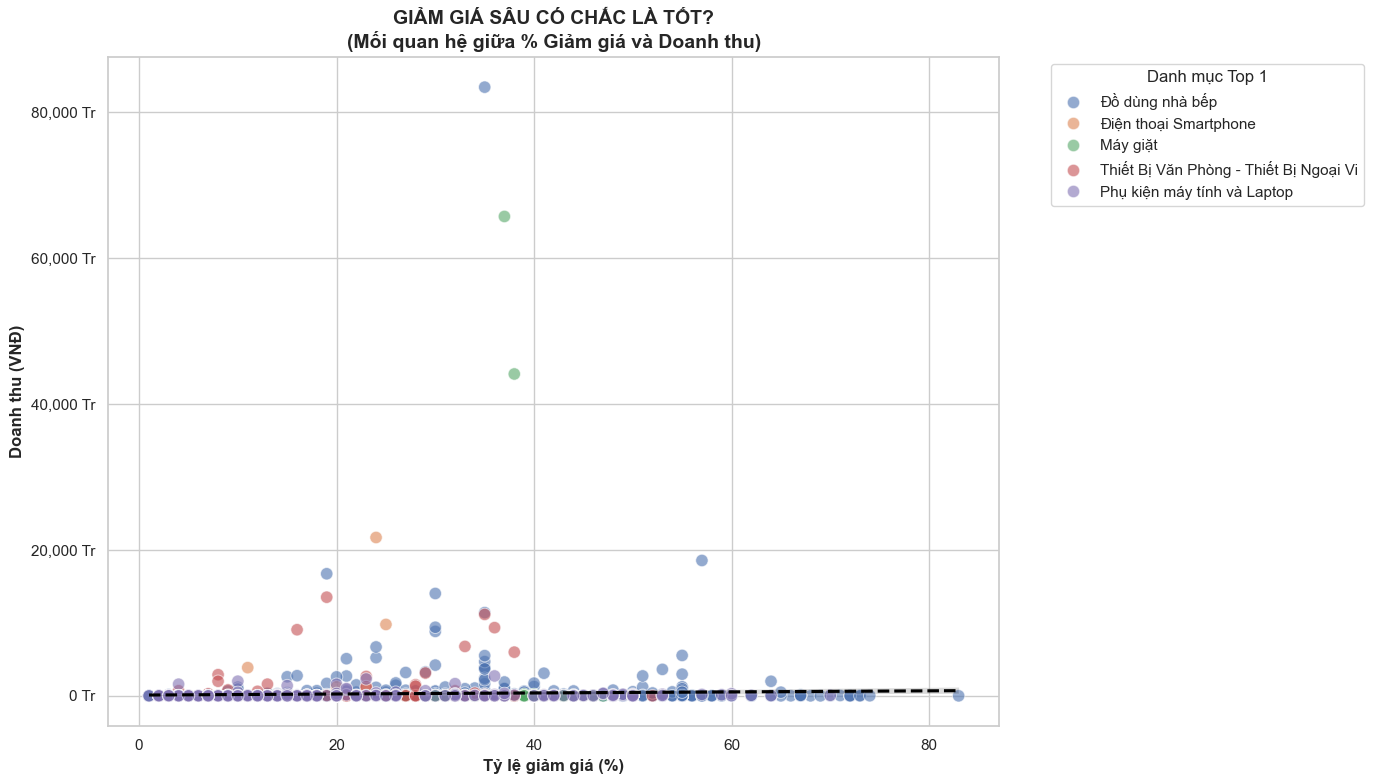

In [54]:
# --- CODE CHO TO-DO 2.2 ---
print("--- KHÁM PHÁ MỐI QUAN HỆ GIỮA GIẢM GIÁ VÀ DOANH THU ---\n")

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

# Vẽ biểu đồ Scatter (Phân tán) để xem giảm giá bao nhiêu thì bán được nhiều tiền nhất
# Dùng hue để tách màu theo từng Danh mục
sns.scatterplot(
    data=df_top_products[df_top_products['discount_percent'] > 0], # Bỏ qua các SP không giảm giá để nhìn rõ
    x='discount_percent', 
    y='revenue', 
    hue='L2_ancestor',
    alpha=0.6,
    s=80 # Kích thước chấm
)

# Thêm đường xu hướng (Trendline) mờ mờ cho toàn bộ dữ liệu
sns.regplot(
    data=df_top_products[df_top_products['discount_percent'] > 0], 
    x='discount_percent', 
    y='revenue', 
    scatter=False, 
    color='black', 
    line_kws={"linestyle": "--"}
)

plt.title('GIẢM GIÁ SÂU CÓ CHẮC LÀ TỐT?\n(Mối quan hệ giữa % Giảm giá và Doanh thu)', fontsize=14, fontweight='bold')
plt.xlabel('Tỷ lệ giảm giá (%)', fontweight='bold')
plt.ylabel('Doanh thu (VNĐ)', fontweight='bold')

# Format trục Y về đơn vị Triệu
from matplotlib.ticker import FuncFormatter
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y/1_000_000:,.0f} Tr'))

plt.legend(title='Danh mục Top 1', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Analysis and Conclusion - Question 2

#### Key Observations:

1. 
2. 
3. 

#### Conclusion:


---
## OVERALL CONCLUSION
